In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [63]:
import pandas as pd
from pathlib import Path
import glob

from config import STATE_STORAGE_PATH

SOURCES_TO_COMPARE = ["deep_rl_pytorch", "hard_coded", "random"]


files = glob.glob(str(Path(STATE_STORAGE_PATH) / "*.jsonl"))

dfs = []
for f in files:
    df = pd.read_json(f, lines=True)
    df["source"] = Path(f).stem
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

In [64]:
data["source"].unique()

array(['all_closed', 'all_open', 'deep_rl', 'deep_rl_pytorch',
       'deep_rl_pytorch_training_log', 'deep_rl_slow', 'hard_coded',
       'inside_open', 'outside_open', 'random'], dtype=object)

In [65]:
start_date = pd.Timestamp("2024-01-01")

data['datetime'] = start_date + pd.to_timedelta(data['current_time'], unit='h')

data = data[data['source'].isin(SOURCES_TO_COMPARE)]

In [66]:
data.head()

,dry_bulb_temperature,total_horizontal_radiation,operative_temperature,hour_of_day,control,current_time,source,type,step,epsilon,action_index,action_value,exploratory,reward,loss,memory_size,datetime
315360,-2.091667,0.0,0.011281,0.083333,0.0,0.083333,deep_rl_pytorch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 00:04:59.999999998
315361,-1.875000,0.0,0.037182,0.166667,-1.0,0.166667,deep_rl_pytorch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 00:10:00.000000001
315362,-1.658333,0.0,0.068668,0.250000,0.0,0.250000,deep_rl_pytorch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 00:15:00.000000000
315363,-1.441667,0.0,0.103977,0.333333,0.0,0.333333,deep_rl_pytorch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 00:19:59.999999998
315364,-1.225000,0.0,0.141913,0.416667,1.0,0.416667,deep_rl_pytorch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 00:25:00.000000001


In [67]:
WEEK_NUMBER = 55

week_length = 24*3

week_interval = ((WEEK_NUMBER - 1) * week_length, WEEK_NUMBER * week_length)

filtered_data = data[(data['current_time'] >= week_interval[0]) & (data['current_time'] < week_interval[1])]

filtered_data.head()


,dry_bulb_temperature,total_horizontal_radiation,operative_temperature,hour_of_day,control,current_time,source,type,step,epsilon,action_index,action_value,exploratory,reward,loss,memory_size,datetime
362015,16.720833,0.0,19.284476,0.000000,1.0,3888.000000,deep_rl_pytorch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-06-11 00:00:00.000000000
362016,16.691667,0.0,19.266460,0.083333,1.0,3888.083333,deep_rl_pytorch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-06-11 00:04:59.999999998
362017,16.675000,0.0,19.253378,0.166667,1.0,3888.166667,deep_rl_pytorch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-06-11 00:10:00.000000001
362018,16.658333,0.0,19.243688,0.250000,1.0,3888.250000,deep_rl_pytorch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-06-11 00:15:00.000000000
362019,16.641667,0.0,19.117269,0.333333,2.0,3888.333333,deep_rl_pytorch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-06-11 00:19:59.999999998


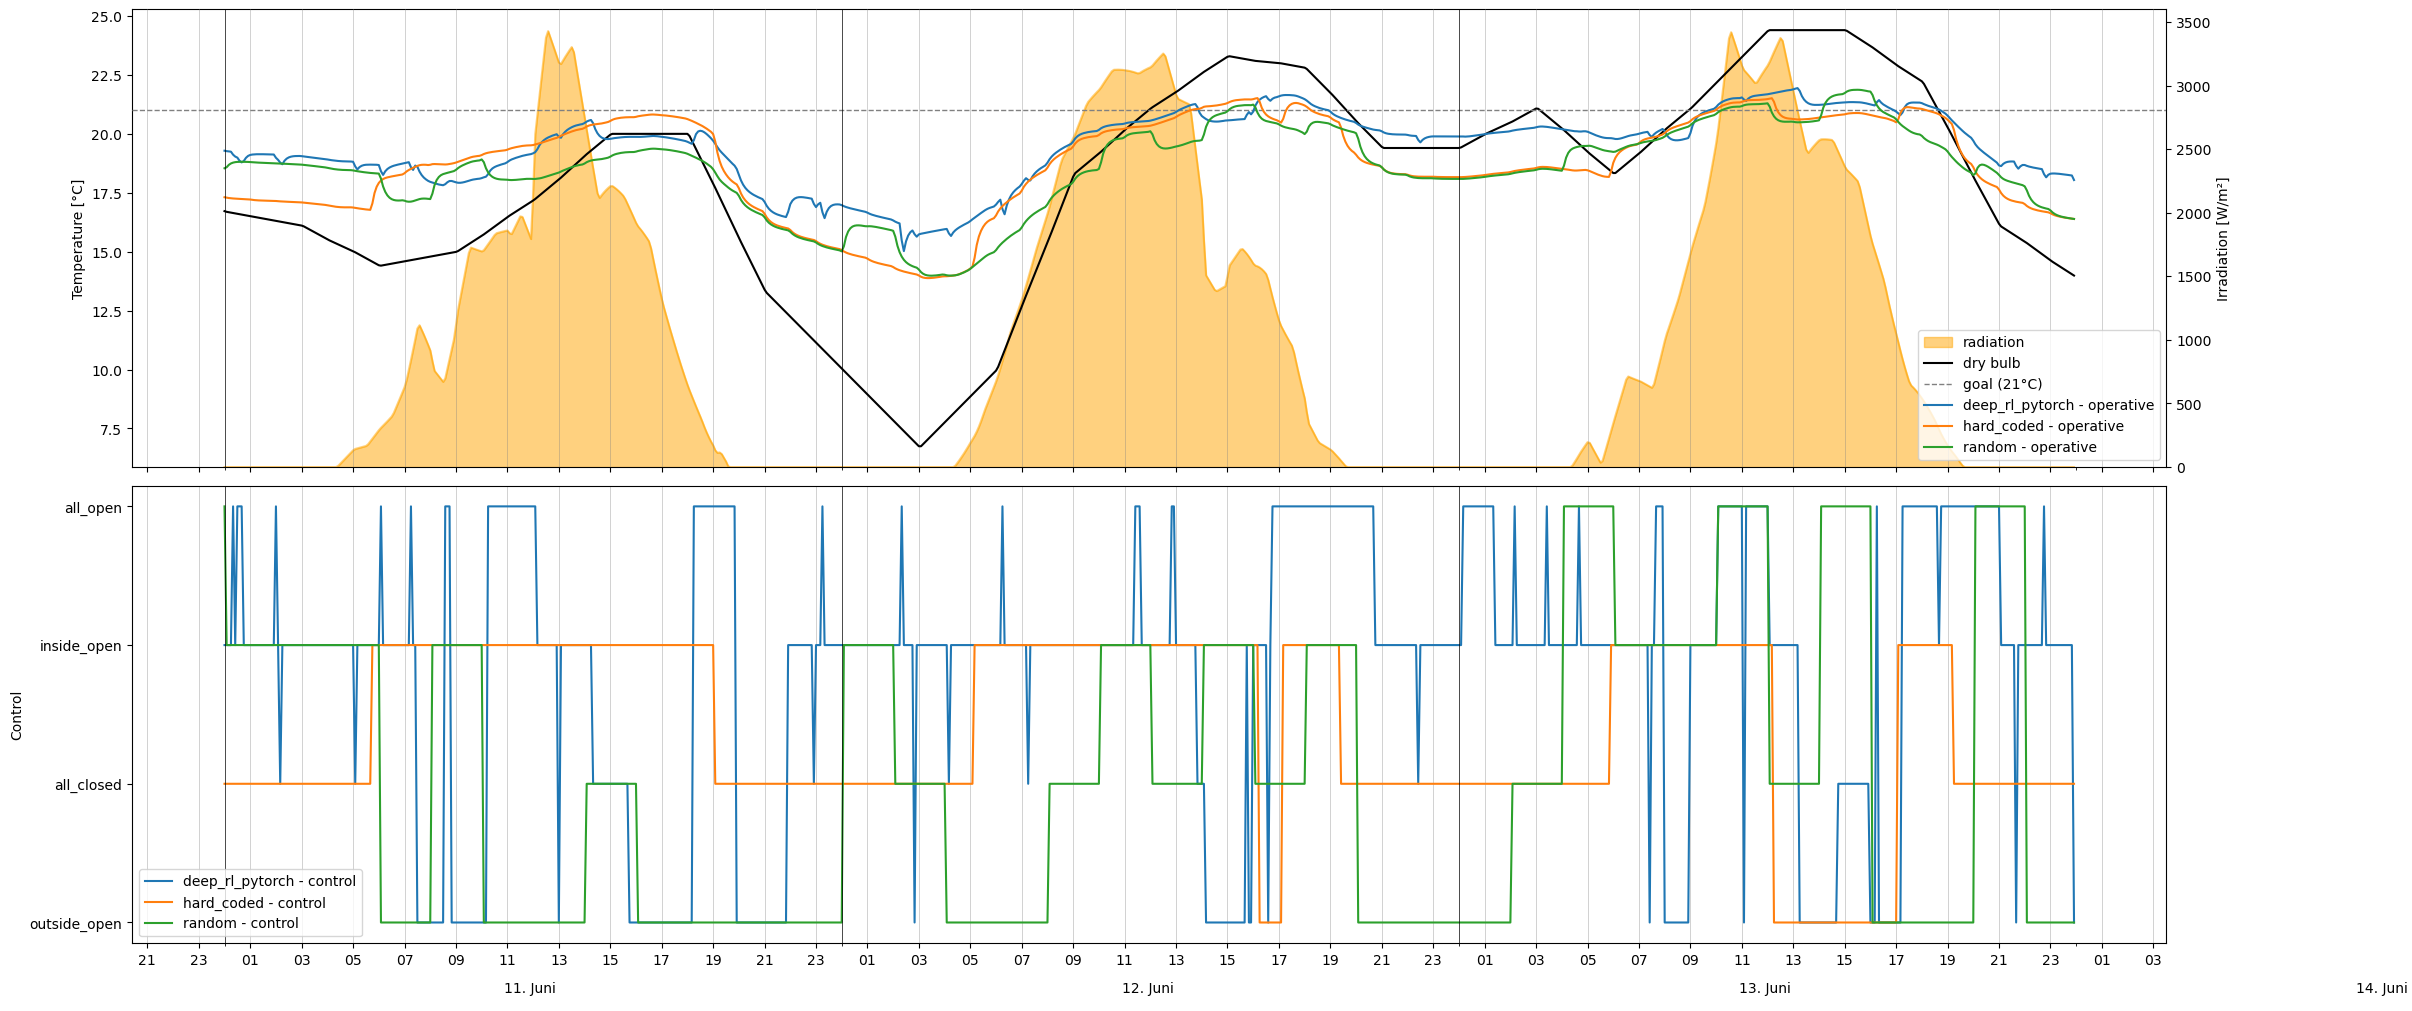

In [68]:
import matplotlib.dates as mdates
import matplotlib.transforms as transforms
import locale
import matplotlib.ticker as mticker

CONTROL_ACTIONS = {
    "all_closed": 0, # for winter night
    "all_open": 2, # for summer night
    "inside_open": 1, # for winter day (with radiation)
    "outside_open": -1 # for summer day
}

locale.setlocale(locale.LC_TIME, "de_DE.UTF-8")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(24, 10), sharex=True, constrained_layout=True)
ax1_rad = ax1.twinx()

colors = {source: color for source, color in zip(filtered_data['source'].unique(), plt.cm.tab10.colors)}

# Plot dry bulb once
first_source = filtered_data['source'].unique()[0]
filtered_data[filtered_data['source'] == first_source].plot(
    kind="line", x="datetime", y="dry_bulb_temperature",
    ax=ax1, color="black", label="dry bulb"
)

# Radiation on second y-axis (once, same across sources)
filtered_data[filtered_data['source'] == first_source].plot(
    kind="area", x="datetime", y="total_horizontal_radiation",
    ax=ax1_rad, color="orange", label="radiation", alpha=0.5
)

ax1_rad.set_zorder(ax1.get_zorder() - 1)
ax1.set_frame_on(False)

# Goal temperature line
ax1.axhline(y=21, color="gray", linestyle="--", linewidth=1, label="goal (21°C)")

for source, subset in filtered_data.groupby('source'):
    color = colors[source]
    subset.plot(kind="line", x="datetime", y="operative_temperature", ax=ax1, color=color, label=f"{source} - operative")
    subset.plot(kind="line", x="datetime", y="control", ax=ax2, color=color, label=f"{source} - control")

ax1.set_ylabel("Temperature [°C]")
lines1, labels1 = ax1.get_legend_handles_labels()
lines_rad, labels_rad = ax1_rad.get_legend_handles_labels()
ax1.legend(lines_rad + lines1, labels_rad + labels1, loc="best")
ax1_rad.set_ylabel("Irradiation [W/m²]")
ax1_rad.get_legend().remove()

ax2.set_ylabel("Control")
ax2.legend(loc="best")

# Split x-axis: hours on top, days on bottom
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H"))

# Hour gridlines
ax1.xaxis.grid(True, which='major', linestyle='-', linewidth=0.5, color='gray', alpha=0.5)
ax2.xaxis.grid(True, which='major', linestyle='-', linewidth=0.5, color='gray', alpha=0.5)

# Day gridlines
day_ticks = mdates.DayLocator().tick_values(filtered_data['datetime'].min(), filtered_data['datetime'].max())
for day in day_ticks:
    ax1.axvline(mdates.num2date(day), linestyle='-', linewidth=0.5, color='black')
    ax2.axvline(mdates.num2date(day), linestyle='-', linewidth=0.5, color='black')

ax2.tick_params(axis='x', which='both', rotation=0)

# Force render first, then set minor locator/formatter
fig.canvas.draw()
ax2.xaxis.set_minor_locator(mdates.DayLocator())
ax2.xaxis.set_minor_formatter(mdates.DateFormatter("\n%#d. %B"))
ax2.tick_params(axis='x', which='minor', rotation=0)

control_labels = {v: k for k, v in CONTROL_ACTIONS.items()}

ax2.yaxis.set_major_locator(mticker.FixedLocator(list(control_labels.keys())))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: control_labels.get(x, "")))

for label in ax2.xaxis.get_majorticklabels():
    label.set_ha('center')

for label in ax2.xaxis.get_minorticklabels():
    label.set_ha('center')
    # Offset by half a day (0.5) in data coordinates
    offset = transforms.ScaledTranslation(0.5, 0, ax2.transData - ax2.transData)
    label.set_transform(label.get_transform() + transforms.ScaledTranslation(
        0.25 / (filtered_data['datetime'].max() - filtered_data['datetime'].min()).days,
        -0.02, fig.transFigure
    ))

ax2.set_xlabel("")
ax1.set_xlabel("")

plt.show()

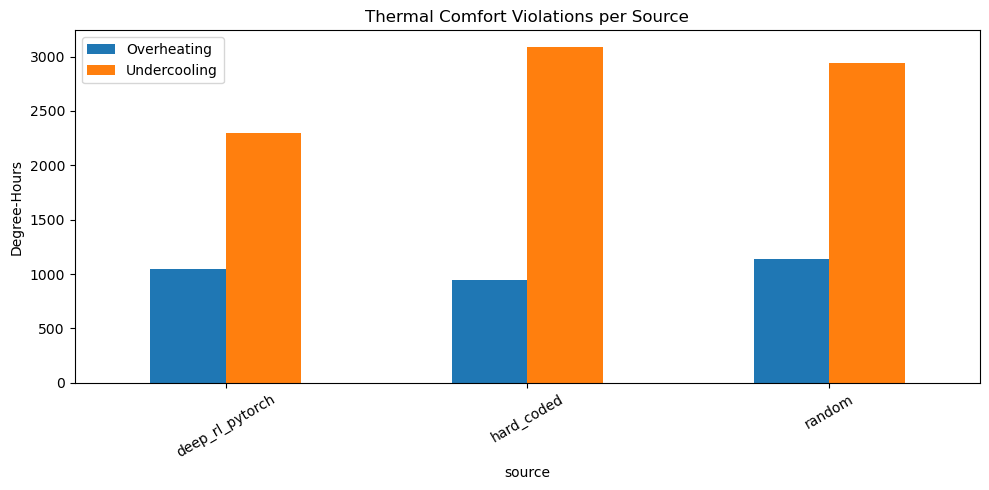

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

T_HIGH = 22
T_LOW = 0

# Overheating (above comfort)
data["overheat"] = (data["operative_temperature"] - T_HIGH).clip(lower=0)

# Undercooling (below comfort)
data["underheat"] = (T_LOW - data["operative_temperature"]).clip(lower=0)

# Aggregate (degree-hours)
ohdh = data.groupby("source")["overheat"].sum() / 12
uhdh = data.groupby("source")["underheat"].sum() / 12

# Combine into one DataFrame
summary = pd.DataFrame({
    "Overheating": ohdh,
    "Undercooling": uhdh
}).sort_index()

# Plot grouped bar
summary.plot(kind="bar", figsize=(10, 5))

plt.ylabel("Degree-Hours")
plt.title("Thermal Comfort Violations per Source")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

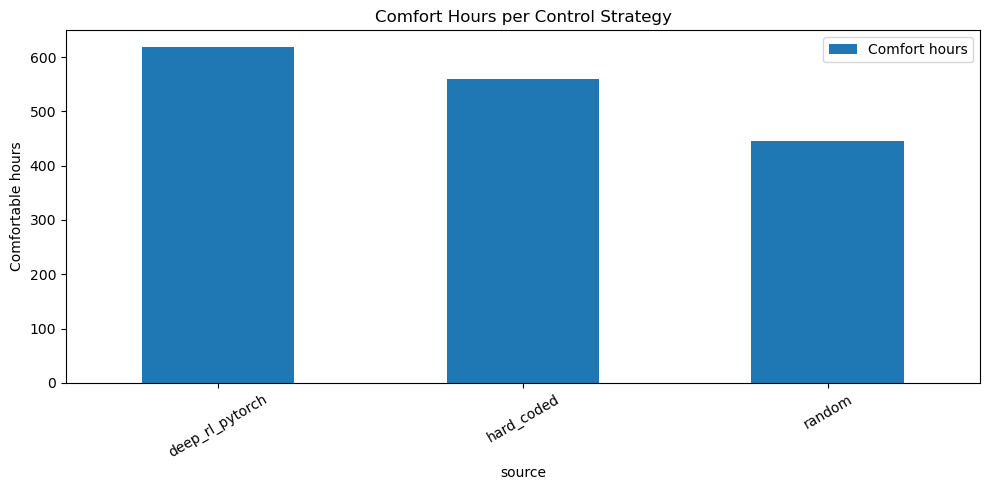

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

T_HIGH = 21.5
T_LOW = 20.5

# comfort mask
data["comfort"] = data["operative_temperature"].between(T_LOW, T_HIGH)

# aggregate
comfort_hours = data.groupby("source")["comfort"].sum() / 12

# build clean summary dataframe
summary = pd.DataFrame({
    "Comfort hours": comfort_hours
}).sort_index()

# plot
summary.plot(kind="bar", figsize=(10, 5))

plt.ylabel("Comfortable hours")
plt.title("Comfort Hours per Control Strategy")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

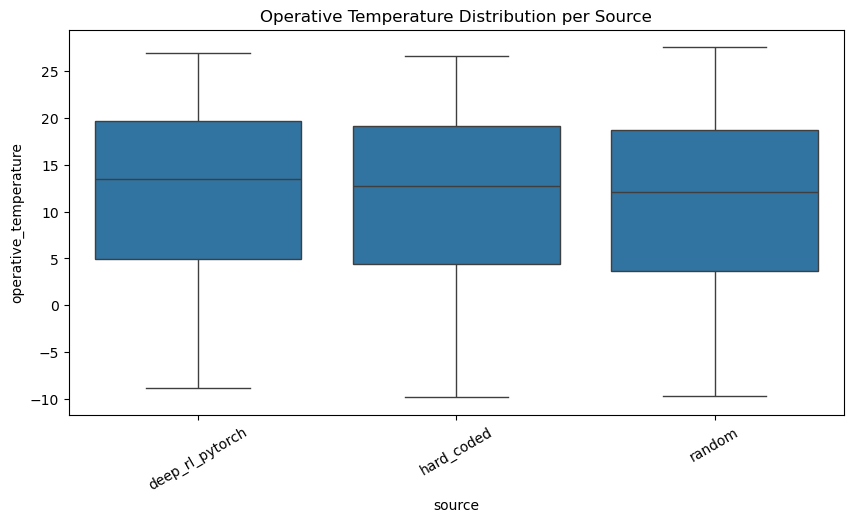

In [71]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=data,
    x="source",
    y="operative_temperature"
)

plt.title("Operative Temperature Distribution per Source")
plt.xticks(rotation=30)
plt.show()

In [72]:
drl_training = pd.read_json(r"C:\Users\lkclu\Documents\GitHub\DTFS\data\deep_rl_pytorch_training_log.jsonl", lines=True)

actions = drl_training[drl_training["type"] == "action"].copy()

actions = actions[actions["exploratory"] == False]

actions["action_text"] = actions["action_value"].map({v: k for k, v in CONTROL_ACTIONS.items()})

actions.head()

,type,step,epsilon,action_index,action_value,exploratory,operative_temperature,dry_bulb_temperature,total_horizontal_radiation,reward,loss,memory_size,action_text
13,action,8,0.8468,1.0,2.0,0.0,0.218063,-0.575000,0.0,NaN,NaN,NaN,all_open
15,action,9,0.8464,1.0,2.0,0.0,0.259235,-0.358333,0.0,NaN,NaN,NaN,all_open
17,action,10,0.8460,1.0,2.0,0.0,0.291799,-0.141667,0.0,NaN,NaN,NaN,all_open
43,action,23,0.8409,1.0,2.0,0.0,0.719689,0.662500,0.0,NaN,NaN,NaN,all_open
49,action,26,0.8397,2.0,1.0,0.0,0.858640,0.750000,0.0,NaN,NaN,NaN,inside_open


In [73]:
import plotly.express as px

actions = actions.sample(1000)

fig = px.scatter_3d(
    actions,
    x="operative_temperature",
    y="dry_bulb_temperature",
    z="total_horizontal_radiation",
    color="action_text",
    color_continuous_scale="Viridis"
)

fig.show()

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.colors as pc

actions = actions.sample(1000)

action_list = sorted(actions["action_text"].unique())
palette = pc.qualitative.Set2
color_map = {a: palette[i % len(palette)] for i, a in enumerate(action_list)}

fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=[
        "Operative vs Dry Bulb",
        "Operative vs Radiation",
        "Dry Bulb vs Radiation"
    ]
)

for action in action_list:
    df = actions[actions["action_text"] == action]

    # shared legend identity
    legendgroup = action

    # 1) subplot 1
    fig.add_trace(
        go.Scatter(
            x=df["operative_temperature"],
            y=df["dry_bulb_temperature"],
            mode="markers",
            name=action,
            legendgroup=legendgroup,
            marker=dict(color=color_map[action]),
            showlegend=True
        ),
        row=1, col=1
    )

    # 2) subplot 2
    fig.add_trace(
        go.Scatter(
            x=df["operative_temperature"],
            y=df["total_horizontal_radiation"],
            mode="markers",
            legendgroup=legendgroup,
            marker=dict(color=color_map[action]),
            showlegend=False
        ),
        row=1, col=2
    )

    # 3) subplot 3
    fig.add_trace(
        go.Scatter(
            x=df["dry_bulb_temperature"],
            y=df["total_horizontal_radiation"],
            mode="markers",
            legendgroup=legendgroup,
            marker=dict(color=color_map[action]),
            showlegend=False
        ),
        row=1, col=3
    )

fig.update_layout(
    title="Action distribution across environmental variables",
    height=500,
    width=1400,
    legend=dict(groupclick="togglegroup")
)

fig.show()